## Getting the data

Request all issues with personified token from github_apikey.key file. One can generate a token under https://github.com/settings/tokens

Downloaded data available on https://gigamove.rwth-aachen.de/de/download/5726f0a388b74818ddd8fdec187bd267

In [1]:
import requests
import time
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
import nltk
from nltk.tokenize import word_tokenize
import re
import ast
import random
import statistics
import math
from pathlib import Path
from typing import List, Dict, Optional
from collections import Counter, defaultdict

In [23]:
TOKEN = "YOUR_PERSONAL_ACCESS_TOKEN" 
if os.path.exists("github_apikey.key"):
    with open("github_apikey.key", 'r') as f:
        TOKEN = f.read().replace("\n", "")

query_template = """
query($cursor: String) {
  rateLimit {
    cost
    remaining
    resetAt
  }
  repository(owner: "%s", name: "%s") {
    issues(
      states: CLOSED, 
      first: 30, 
      after: $cursor
    ) {
      pageInfo {
        hasNextPage
        endCursor
      }
      nodes {
        number
        title
        body
        createdAt
        author {
          login
        }
        labels(first: 20) {
          nodes {
            name
          }
        }
        comments(first: 100) {
          nodes {
            author {
              login
            }
            body
          }
        }
      }
    }
  }
}
"""


In [24]:
def run_query(owner, repo, cursor):
    url = 'https://api.github.com/graphql'
    headers = {"Authorization": f"Bearer {TOKEN}"}
    variables = {"cursor": cursor}
    
    try:
        response = requests.post(url, json={'query': query_template % (owner, repo), 'variables': variables}, headers=headers, timeout=30)
        if response.status_code == 200:
            return response.json()
        else:
            print(f"Error {response.status_code}: {response.text}")
            return None
    except Exception as e:
        print(f"Connection Error: {e}")
        return None

In [25]:
def request_all_issues(owner, repo):
    has_next = True
    cursor = None
    total_issues_processed = 0

    raw_data = open("raw_data_"+repo+".txt", 'w', encoding='utf-8')

    while has_next:
        result = run_query(owner, repo, cursor)
        
        # Check for empty result or connection failure
        if not result:
            print("Network error. Sleeping 5s...")
            time.sleep(5)
            continue

        # Check for GraphQL specific errors (e.g., Bad syntax)
        if 'errors' in result:
            print(f"GraphQL Error: {result['errors']}")
            break # Break loop, otherwise it retries infinitely

        # Check if data exists
        if 'data' not in result or not result['data']:
            print("No data returned.")
            break
        
        data = result['data']
        
        if 'rateLimit' in data:
            rate_limit = data['rateLimit']
            remaining = rate_limit['remaining']
            print(f"Points remaining: {remaining} (Cost: {rate_limit['cost']})")
            
            if remaining < 100:
                print("RATE LIMIT NEAR! Sleeping for 1 hour...")
                time.sleep(3600)
        
        data_repo = data['repository']['issues']
        
        for issue in data_repo['nodes']:
            if not issue or not issue['author'] or not issue['title'] or not issue['body']: 
                continue
            
            issue_id = str(issue['number'])
            issue_author = issue['author']['login']

            issue_title = issue['title'].replace("\n", " ").replace("\r", "")
            issue_body = issue['body'].replace("\n", " ").replace("\r", "")
            issue_date = issue['createdAt']

            label_list = []
            if 'labels' in issue and issue['labels']['nodes']:
                label_list = [l['name'] for l in issue['labels']['nodes']]
            
            label_str = "|".join(label_list)

            raw_data.write(f"issue:{issue_author}\n{label_str}\n{issue_date}\n{issue_title}\n{issue_body}\n")

            if 'comments' in issue and issue['comments']['nodes']:
                for comment in issue['comments']['nodes']:
                    if not comment or not comment['author'] or not comment['body']: 
                        continue
                    
                    comment_author = comment['author']['login']
                    
                    comment_body = comment['body'].replace("\n", " ").replace("\r", "")

                    raw_data.write(f"comment:{comment_author}\n{comment_body}\n")

        # Update Progress
        total_issues_processed += len(data_repo['nodes'])
        has_next = data_repo['pageInfo']['hasNextPage']
        cursor = data_repo['pageInfo']['endCursor']
        
        print(f"Total issues saved: {total_issues_processed}")

    raw_data.close()
    print("Done")

In [ ]:
#request_all_issues("tensorflow", "tensorflow")

In [ ]:
#request_all_issues("networkx", "networkx")

In [ ]:
#request_all_issues("pandas-dev", "pandas")

## Building the graph

In the following we build the tensorflow, pandas, and networkx graph. 

For each graph we connect each commenter of an issue to the issue opener.

In [4]:
G_tensorflow = nx.DiGraph()

def build_graph(raw_data_path):
    read_raw_data = open(raw_data_path, 'r', encoding='utf-8')

    G = nx.DiGraph()

    current_issue_opener = ""

    for line in read_raw_data:
        if line.startswith("issue:"):
            current_issue_opener = line.strip().split(':')[1]
        elif line.startswith("comment:"):
            commentor = line.strip().split(':')[1]
            if commentor != current_issue_opener: 
                G.add_edge(commentor, current_issue_opener)

    read_raw_data.close()
    print(G)
    return G

In [5]:
G_tensorflow = build_graph("raw_data_tensorflow.txt")

DiGraph with 42897 nodes and 112810 edges


In [6]:
G_pandas = build_graph("raw_data_pandas.txt")

DiGraph with 14738 nodes and 31709 edges


In [7]:
G_networkx = build_graph("raw_data_networkx.txt")

DiGraph with 1696 nodes and 2858 edges


**So that every of our measurements is defined we take the largest weakly connect component as the graph.**

**The resulting graphs are:**

In [8]:
largest = max(nx.weakly_connected_components(G_tensorflow), key=len)
G_tensorflow = G_tensorflow.subgraph(largest)

largest = max(nx.weakly_connected_components(G_pandas), key=len)
G_pandas = G_pandas.subgraph(largest)

largest = max(nx.weakly_connected_components(G_networkx), key=len)
G_networkx = G_networkx.subgraph(largest)

print("The tensorflow graph is a " + str(G_tensorflow))
print("The pandas graph is a " + str(G_pandas))
print("The networkx graph is a " + str(G_networkx))

The tensorflow graph is a DiGraph with 42785 nodes and 112749 edges
The pandas graph is a DiGraph with 14648 nodes and 31662 edges
The networkx graph is a DiGraph with 1680 nodes and 2850 edges


**The first thing we want to look at is the degree distribution**

**First we get the in- and out-degrees for all networks**

In [9]:
in_degree_sequence_tensorflow = sorted([d for d in G_tensorflow.in_degree()], key=lambda x: x[1], reverse=True)
out_degree_sequence_tensorflow = sorted([d for d in G_tensorflow.out_degree()], key=lambda x: x[1], reverse=True)

in_degree_sequence_pandas = sorted([d for d in G_pandas.in_degree()], key=lambda x: x[1], reverse=True)
out_degree_sequence_pandas = sorted([d for d in G_pandas.out_degree()], key=lambda x: x[1], reverse=True)

in_degree_sequence_networkx = sorted([d for d in G_networkx.in_degree()], key=lambda x: x[1], reverse=True)
out_degree_sequence_networkx = sorted([d for d in G_networkx.out_degree()], key=lambda x: x[1], reverse=True)

**Then we calculate the median and average degrees**

In [10]:
print("Tensorflow network:")
print(f"The median of the in degree is {in_degree_sequence_tensorflow[int(len(in_degree_sequence_tensorflow)/2)][1]} and also for the out degree it is {out_degree_sequence_tensorflow[int(len(out_degree_sequence_tensorflow)/2)][1]}.")
print(f"The average degree is {sum([x[1] for x in in_degree_sequence_tensorflow])/len(in_degree_sequence_tensorflow):.4f}.")

Tensorflow network:
The median of the in degree is 1 and also for the out degree it is 1.
The average degree is 2.6352.


In [11]:
print("Pandas network:")
print(f"The median of the in degree is {in_degree_sequence_pandas[int(len(in_degree_sequence_pandas)/2)][1]} and also for the out degree it is {out_degree_sequence_pandas[int(len(out_degree_sequence_pandas)/2)][1]}.")
print(f"The average degree is {sum([x[1] for x in in_degree_sequence_pandas])/len(in_degree_sequence_pandas):.4f}.")

Pandas network:
The median of the in degree is 1 and also for the out degree it is 1.
The average degree is 2.1615.


In [12]:
print("NetworkX network:")
print(f"The median of the in degree is {in_degree_sequence_networkx[int(len(in_degree_sequence_networkx)/2)][1]} and also for the out degree it is {out_degree_sequence_networkx[int(len(out_degree_sequence_networkx)/2)][1]}.")
print(f"The average degree is {sum([x[1] for x in in_degree_sequence_networkx])/len(in_degree_sequence_networkx):.4f}.")

NetworkX network:
The median of the in degree is 1 and also for the out degree it is 0.
The average degree is 1.6964.


**Next we plot the in- and out-degree distribution for each network**

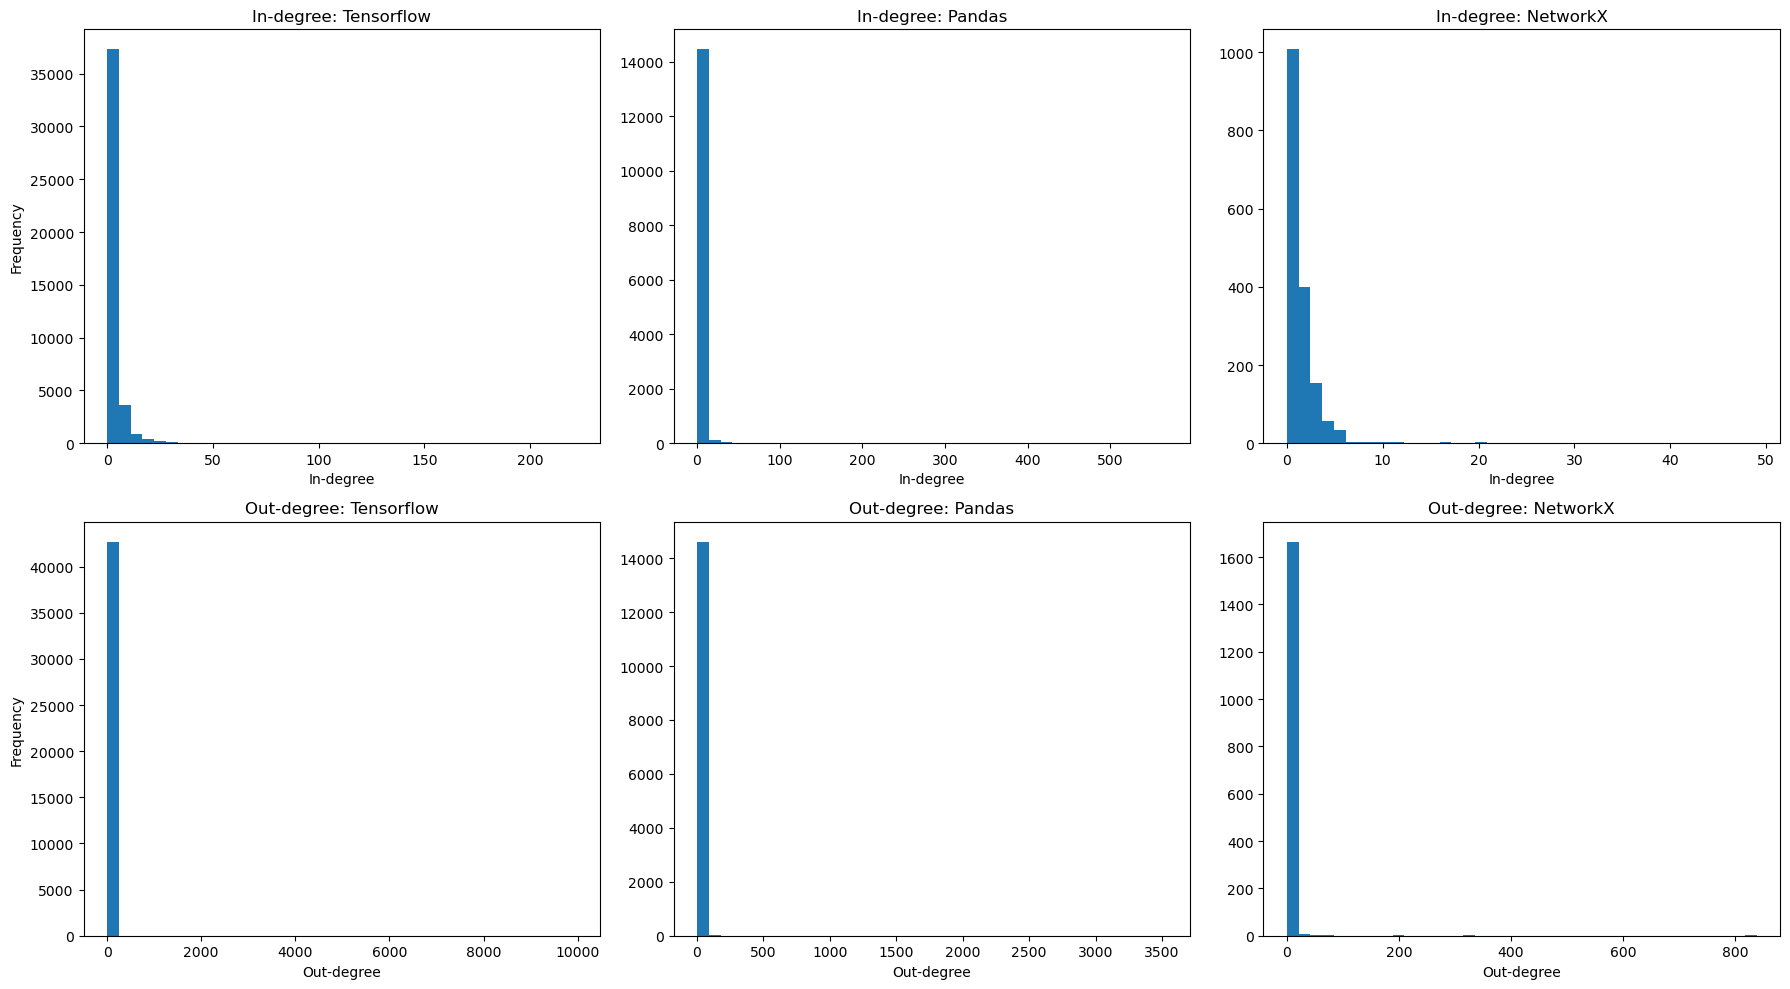

In [13]:
number_bins = 40

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Tensorflow In-degree
axes[0, 0].hist([x[1] for x in in_degree_sequence_tensorflow], bins=number_bins)
axes[0, 0].set_title("In-degree: Tensorflow")
axes[0, 0].set_xlabel("In-degree")
axes[0, 0].set_ylabel("Frequency")

# Pandas In-degree
axes[0, 1].hist([x[1] for x in in_degree_sequence_pandas], bins=number_bins)
axes[0, 1].set_title("In-degree: Pandas")
axes[0, 1].set_xlabel("In-degree")

# NetworkX In-degree
axes[0, 2].hist([x[1] for x in in_degree_sequence_networkx], bins=number_bins)
axes[0, 2].set_title("In-degree: NetworkX")
axes[0, 2].set_xlabel("In-degree")


# Tensorflow Out-degree
axes[1, 0].hist([x[1] for x in out_degree_sequence_tensorflow], bins=number_bins)
axes[1, 0].set_title("Out-degree: Tensorflow")
axes[1, 0].set_xlabel("Out-degree")
axes[1, 0].set_ylabel("Frequency")

# Pandas Out-degree
axes[1, 1].hist([x[1] for x in out_degree_sequence_pandas], bins=number_bins)
axes[1, 1].set_title("Out-degree: Pandas")
axes[1, 1].set_xlabel("Out-degree")

# NetworkX Out-degree
axes[1, 2].hist([x[1] for x in out_degree_sequence_networkx], bins=number_bins)
axes[1, 2].set_title("Out-degree: NetworkX")
axes[1, 2].set_xlabel("Out-degree")

plt.tight_layout()
plt.show()

We clearly see that we have scale free networks

**Next we calculate the percentages of nodes that have an in- and out-degree of 0 or 1.**

In [14]:
print(f"The percantage of nodes that have an in-degree of 0 or 1 in the tensorflow network is {len([x for x in in_degree_sequence_tensorflow if x[1]<=1])/len(in_degree_sequence_tensorflow)*100:.2f}%.")
print(f"The percantage of nodes that have an out-degree of 0 or 1 in the tensorflow network is {len([x for x in out_degree_sequence_tensorflow if x[1]<=1])/len(out_degree_sequence_tensorflow)*100:.2f}%.")

The percantage of nodes that have an in-degree of 0 or 1 in the tensorflow network is 56.75%.
The percantage of nodes that have an out-degree of 0 or 1 in the tensorflow network is 85.03%.


In [15]:
print(f"The percantage of nodes that have an in-degree of 0 or 1 in the pandas network is {len([x for x in in_degree_sequence_pandas if x[1]<=1])/len(in_degree_sequence_pandas)*100:.2f}%.")
print(f"The percantage of nodes that have an out-degree of 0 or 1 in the pandas network is {len([x for x in out_degree_sequence_pandas if x[1]<=1])/len(out_degree_sequence_pandas)*100:.2f}%.")

The percantage of nodes that have an in-degree of 0 or 1 in the pandas network is 59.45%.
The percantage of nodes that have an out-degree of 0 or 1 in the pandas network is 87.54%.


In [16]:
print(f"The percantage of nodes that have an in-degree of 0 or 1 in the networkx network is {len([x for x in in_degree_sequence_networkx if x[1]<=1])/len(in_degree_sequence_networkx)*100:.2f}%.")
print(f"The percantage of nodes that have an out-degree of 0 or 1 in the networkx network is {len([x for x in out_degree_sequence_networkx if x[1]<=1])/len(out_degree_sequence_networkx)*100:.2f}%.")

The percantage of nodes that have an in-degree of 0 or 1 in the networkx network is 60.00%.
The percantage of nodes that have an out-degree of 0 or 1 in the networkx network is 92.80%.


**Next we want to check if the scale free property when we only look at nodes that have a certain number of interactions (we look at the top ~5% of nodes)**

In [17]:
cutoff = 10

print("Tensorflow network:")
print(f"The number of nodes that have an in-degree of less than {cutoff} is {len([x for x in in_degree_sequence_tensorflow if x[1]<cutoff])/len(in_degree_sequence_tensorflow)*100:.2f}%.")
print(f"The number of nodes that have an out-degree of less than {cutoff} is {len([x for x in out_degree_sequence_tensorflow if x[1]<cutoff])/len(out_degree_sequence_tensorflow)*100:.2f}%.")

Tensorflow network:
The number of nodes that have an in-degree of less than 10 is 94.21%.
The number of nodes that have an out-degree of less than 10 is 98.84%.


In [18]:
print("Pandas network:")
print(f"The number of nodes that have an in-degree of less than {cutoff} is {len([x for x in in_degree_sequence_pandas if x[1]<cutoff])/len(in_degree_sequence_pandas)*100:.2f}%.")
print(f"The number of nodes that have an out-degree of less than {cutoff} is {len([x for x in out_degree_sequence_pandas if x[1]<cutoff])/len(out_degree_sequence_pandas)*100:.2f}%.")

Pandas network:
The number of nodes that have an in-degree of less than 10 is 97.03%.
The number of nodes that have an out-degree of less than 10 is 98.94%.


In [19]:
print("Networkx network:")
print(f"The number of nodes that have an in-degree of less than {cutoff} is {len([x for x in in_degree_sequence_networkx if x[1]<cutoff])/len(in_degree_sequence_networkx)*100:.2f}%.")
print(f"The number of nodes that have an out-degree of less than {cutoff} is {len([x for x in out_degree_sequence_networkx if x[1]<cutoff])/len(out_degree_sequence_networkx)*100:.2f}%.")

Networkx network:
The number of nodes that have an in-degree of less than 10 is 98.81%.
The number of nodes that have an out-degree of less than 10 is 98.87%.


In [20]:
in_tensorflow_greater_cutoff = [d for d in G_tensorflow.in_degree() if d[1] >= cutoff]
out_tensorflow_greater_cutoff = [d for d in G_tensorflow.out_degree() if d[1] >= cutoff]

in_pandas_greater_cutoff = [d for d in G_pandas.in_degree() if d[1] >= cutoff]
out_pandas_greater_cutoff = [d for d in G_pandas.out_degree() if d[1] >= cutoff]

in_networkx_greater_cutoff = [d for d in G_networkx.in_degree() if d[1] >= cutoff]
out_networkx_greater_cutoff = [d for d in G_networkx.out_degree() if d[1] >= cutoff]

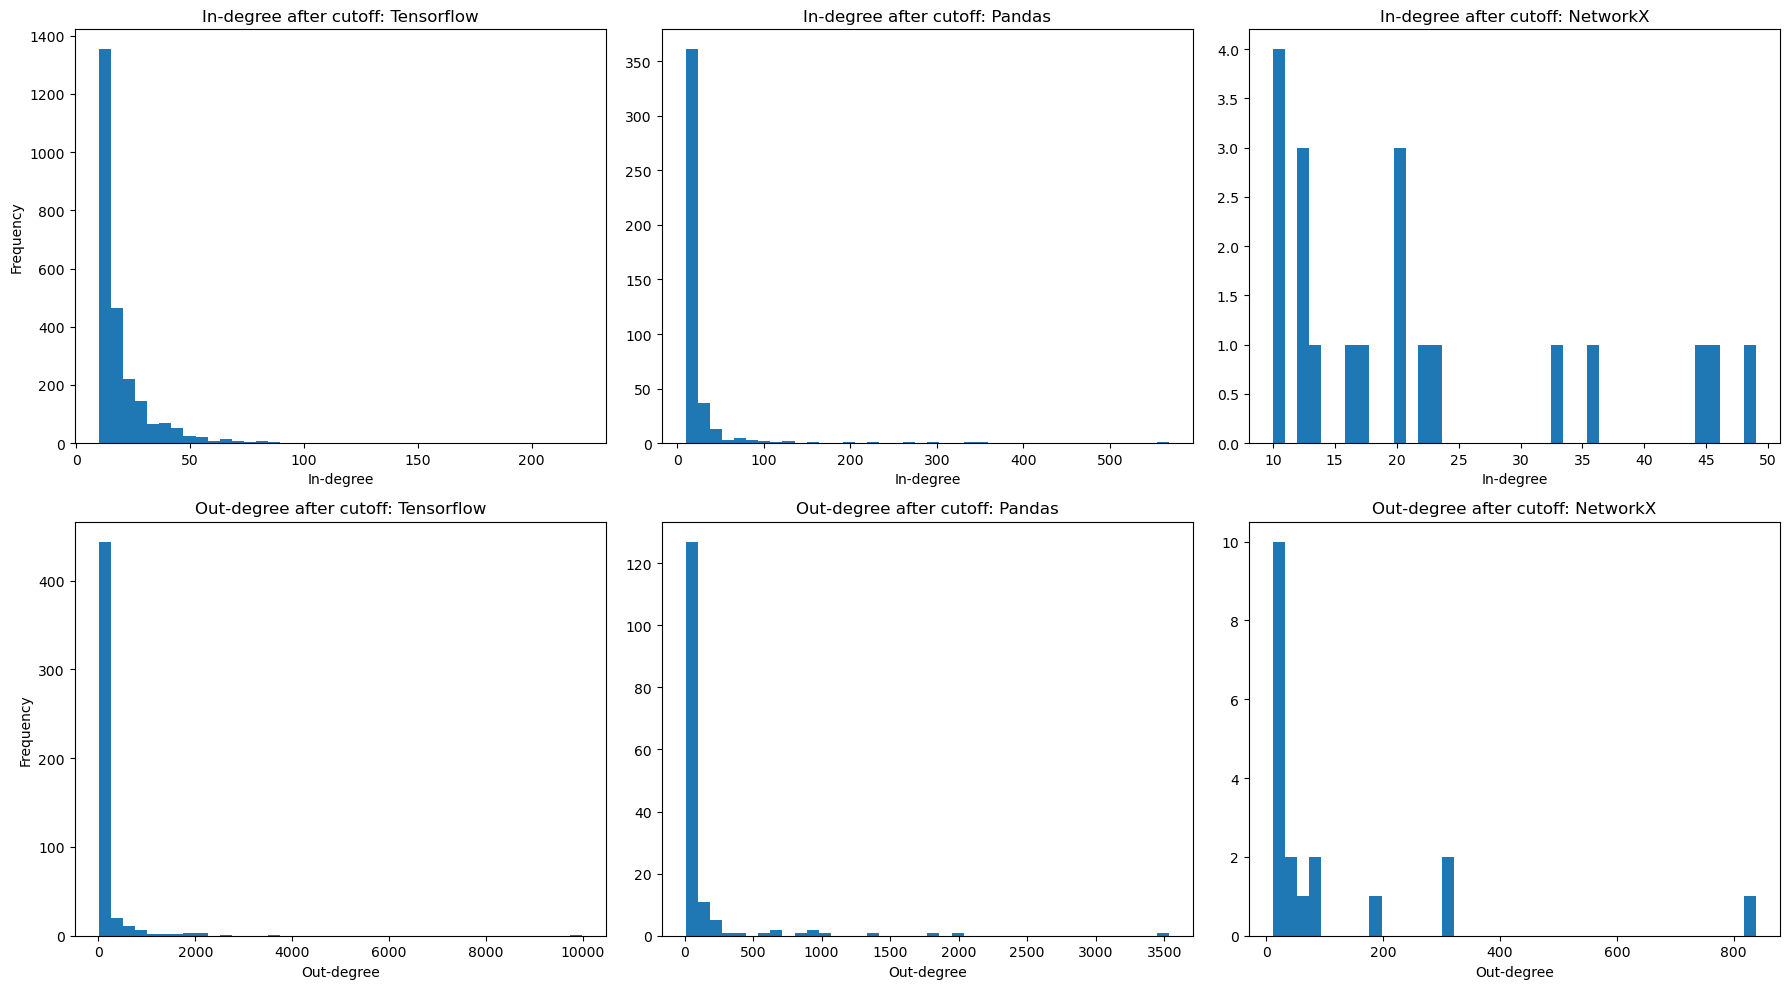

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Tensorflow In-degree
axes[0, 0].hist([x[1] for x in in_tensorflow_greater_cutoff], bins=number_bins)
axes[0, 0].set_title("In-degree after cutoff: Tensorflow")
axes[0, 0].set_xlabel("In-degree")
axes[0, 0].set_ylabel("Frequency")

# Pandas In-degree
axes[0, 1].hist([x[1] for x in in_pandas_greater_cutoff], bins=number_bins)
axes[0, 1].set_title("In-degree after cutoff: Pandas")
axes[0, 1].set_xlabel("In-degree")

# NetworkX In-degree
axes[0, 2].hist([x[1] for x in in_networkx_greater_cutoff], bins=number_bins)
axes[0, 2].set_title("In-degree after cutoff: NetworkX")
axes[0, 2].set_xlabel("In-degree")


# Tensorflow Out-degree
axes[1, 0].hist([x[1] for x in out_tensorflow_greater_cutoff], bins=number_bins)
axes[1, 0].set_title("Out-degree after cutoff: Tensorflow")
axes[1, 0].set_xlabel("Out-degree")
axes[1, 0].set_ylabel("Frequency")

# Pandas Out-degree
axes[1, 1].hist([x[1] for x in out_pandas_greater_cutoff], bins=number_bins)
axes[1, 1].set_title("Out-degree after cutoff: Pandas")
axes[1, 1].set_xlabel("Out-degree")

# NetworkX Out-degree
axes[1, 2].hist([x[1] for x in out_networkx_greater_cutoff], bins=number_bins)
axes[1, 2].set_title("Out-degree after cutoff: NetworkX")
axes[1, 2].set_xlabel("Out-degree")

plt.tight_layout()
plt.show()

We see that the scale free still mostly holds in the top ~5% of users.

**Next we want to look at the top 10 users for each network regarding in- and out-degree.**

In [22]:
df_top10_in_tensorflow = pd.DataFrame(in_degree_sequence_tensorflow[0:10], columns=('User', ''))
df_top10_out_tensorflow = pd.DataFrame(out_degree_sequence_tensorflow[0:10], columns=('User', ''))

df_top10_in_pandas = pd.DataFrame(in_degree_sequence_pandas[0:10], columns=('User', ''))
df_top10_out_pandas = pd.DataFrame(out_degree_sequence_pandas[0:10], columns=('User', ''))

df_top10_in_networkx = pd.DataFrame(in_degree_sequence_networkx[0:10], columns=('User', ''))
df_top10_out_networkx = pd.DataFrame(out_degree_sequence_networkx[0:10], columns=('User', ''))

frames = {
    ('TensorFlow', 'In-Degree'): df_top10_in_tensorflow,
    ('TensorFlow', 'Out-Degree'): df_top10_out_tensorflow,
    ('Pandas', 'In-Degree'): df_top10_in_pandas,
    ('Pandas', 'Out-Degree'): df_top10_out_pandas,
    ('NetworkX', 'In-Degree'): df_top10_in_networkx,
    ('NetworkX', 'Out-Degree'): df_top10_out_networkx,
}

combined_df = pd.concat(
    [df.reset_index(drop=True) for df in frames.values()], 
    axis=1, 
    keys=frames.keys()
)

print(combined_df.to_string(index=False))

     TensorFlow                                       Pandas                                  NetworkX                      
      In-Degree           Out-Degree               In-Degree             Out-Degree          In-Degree        Out-Degree    
           User                 User                    User                   User               User              User    
     yaroslavvb 222 google-ml-butler 9979            jreback 568            jreback 3534       dschult 49        dschult 838
      cancan101 189 tensorflowbutler 3513 jorisvandenbossche 345          mroeschke 1983       rossbar 46        hagberg 320
       ppwwyyxx 174   github-actions 2662      TomAugspurger 334      TomAugspurger 1835       MridulS 45        rossbar 316
     alanpurple 146       tilakrayal 2123       MarcoGorelli 291 jorisvandenbossche 1415 networkx-trac 36        MridulS 194
dynamicwebpaige 137           ymodak 2100     datapythonista 265         rhshadrach 1062 jarrodmillman 33       chebee7i  81


In [23]:
def get_top_contributors(owner, repo):
    url = f"https://api.github.com/repos/{owner}/{repo}/contributors?per_page=50"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        return [user['login'] for user in data]
    else:
        print(f"Error fetching {repo}: Status {response.status_code}")
        print("You may have hit the GitHub API rate limit.")
        return []

top_50_tf = get_top_contributors('tensorflow', 'tensorflow')
top_50_pandas = get_top_contributors('pandas-dev', 'pandas')
top_50_nx = get_top_contributors('networkx', 'networkx')

print(f"Fetched: {len(top_50_tf)} TF users, {len(top_50_pandas)} Pandas users, {len(top_50_nx)} NX users.")

Error fetching networkx: Status 403
You may have hit the GitHub API rate limit.
Fetched: 50 TF users, 50 Pandas users, 0 NX users.


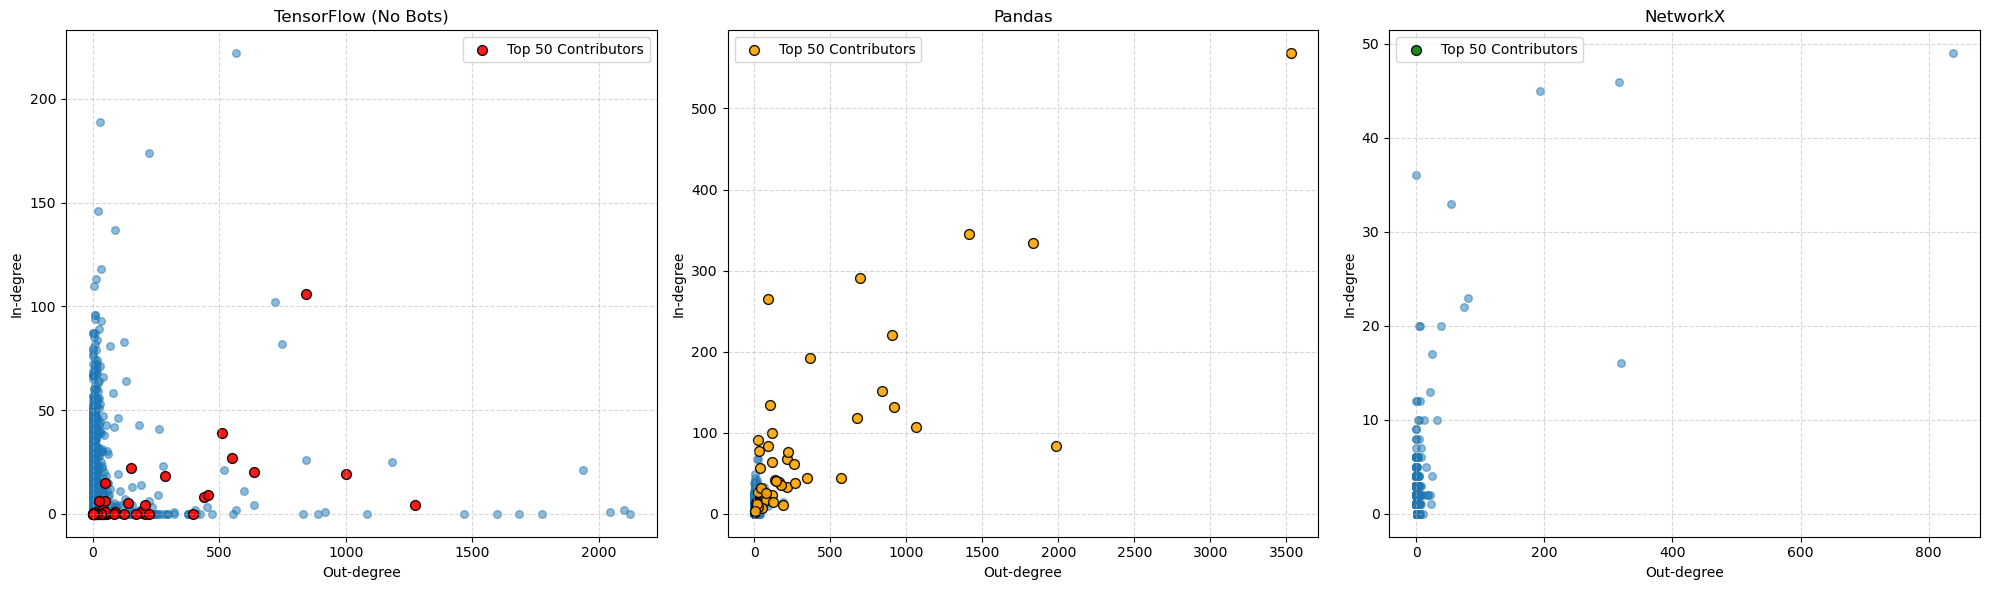

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

# TensorFlow
in_degrees = dict(G_tensorflow.in_degree())
out_degrees = dict(G_tensorflow.out_degree())
bots = ['google-ml-butler', 'tensorflowbutler', 'github-actions', 'tensorflow-bot']
nodes = list(G_tensorflow.nodes())

# Separate data into two groups
x_rest, y_rest = [], []
x_top, y_top = [], []

for n in nodes:
    if n in bots:
        continue # Skip bots
    
    x = out_degrees[n]
    y = in_degrees[n]
    
    if n in top_50_tf:
        x_top.append(x)
        y_top.append(y)
    else:
        x_rest.append(x)
        y_rest.append(y)

# Plot "Rest" in grey/blue
axs[0].scatter(x_rest, y_rest, alpha=0.5, s=30, color='tab:blue')
# Plot "Top 50" in distinct red 
axs[0].scatter(x_top, y_top, alpha=0.9, s=50, c='red', edgecolors='black', label='Top 50 Contributors')

axs[0].set_xlabel("Out-degree")
axs[0].set_ylabel("In-degree")
axs[0].set_title("TensorFlow (No Bots)")
axs[0].legend()
axs[0].grid(True, linestyle="--", alpha=0.5)

# Pandas
in_degrees = dict(G_pandas.in_degree())
out_degrees = dict(G_pandas.out_degree())
nodes = list(G_pandas.nodes())

x_rest, y_rest = [], []
x_top, y_top = [], []

for n in nodes:
    x = out_degrees[n]
    y = in_degrees[n]
    
    if n in top_50_pandas:
        x_top.append(x)
        y_top.append(y)
    else:
        x_rest.append(x)
        y_rest.append(y)

axs[1].scatter(x_rest, y_rest, alpha=0.5, s=30, color='tab:blue')
axs[1].scatter(x_top, y_top, alpha=0.9, s=50, c='orange', edgecolors='black', label='Top 50 Contributors')

axs[1].set_xlabel("Out-degree")
axs[1].set_ylabel("In-degree")
axs[1].set_title("Pandas")
axs[1].legend()
axs[1].grid(True, linestyle="--", alpha=0.5)

# NetworkX
in_degrees = dict(G_networkx.in_degree())
out_degrees = dict(G_networkx.out_degree())
nodes = list(G_networkx.nodes())

x_rest, y_rest = [], []
x_top, y_top = [], []

for n in nodes:
    x = out_degrees[n]
    y = in_degrees[n]
    
    if n in top_50_nx:
        x_top.append(x)
        y_top.append(y)
    else:
        x_rest.append(x)
        y_rest.append(y)

axs[2].scatter(x_rest, y_rest, alpha=0.5, s=30, color='tab:blue')
axs[2].scatter(x_top, y_top, alpha=0.9, s=50, c='green', edgecolors='black', label='Top 50 Contributors')

axs[2].set_xlabel("Out-degree")
axs[2].set_ylabel("In-degree")
axs[2].set_title("NetworkX")
axs[2].legend()
axs[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [25]:
both_tensorflow_pandas = [d for d in G_tensorflow.nodes() if d in G_pandas]
both_tensorflow_networkx = [d for d in G_tensorflow.nodes() if d in G_networkx]
both_pandas_networkx = [d for d in G_pandas.nodes() if d in G_networkx]
in_all_networks = [d for d in G_tensorflow.nodes() if d in G_pandas and d in G_networkx]

print(f"There are {len(both_tensorflow_pandas)} users that appear in both the Tensorflow, as well as in the pandas network.")
print(f"There are {len(both_tensorflow_networkx)} users that appear in both the Tensorflow, as well as in the Networkx network.")
print(f"There are {len(both_pandas_networkx)} users that appear in both the pandas, as well as in the Networkx network.")
print(f"There are {len(in_all_networks)} users that appear in all 3 networks.")

There are 1028 users that appear in both the Tensorflow, as well as in the pandas network.
There are 121 users that appear in both the Tensorflow, as well as in the Networkx network.
There are 205 users that appear in both the pandas, as well as in the Networkx network.
There are 42 users that appear in all 3 networks.


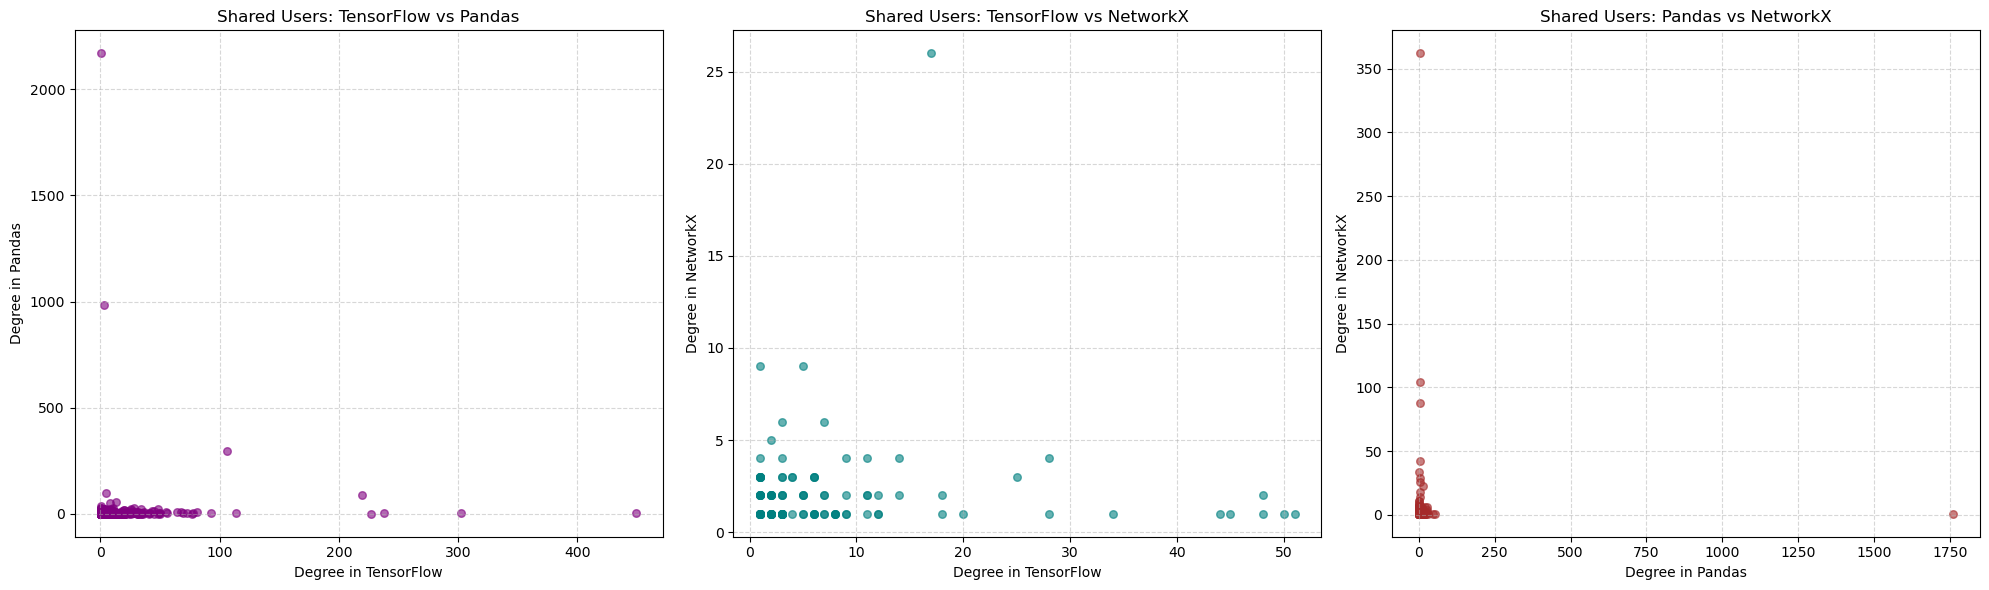

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: TensorFlow vs Pandas ---
degree_tensorflow = []
degree_pandas = []

for user in both_tensorflow_pandas:
    degree_tensorflow.append(G_tensorflow.degree()[user])
    degree_pandas.append(G_pandas.degree()[user])

axs[0].scatter(degree_tensorflow, degree_pandas, alpha=0.6, s=30, color='purple')
axs[0].set_xlabel("Degree in TensorFlow")
axs[0].set_ylabel("Degree in Pandas")
axs[0].set_title("Shared Users: TensorFlow vs Pandas")
axs[0].grid(True, linestyle="--", alpha=0.5)


# --- Plot 2: TensorFlow vs NetworkX ---
degree_tensorflow = []
degree_networkx = []

for user in both_tensorflow_networkx:
    degree_tensorflow.append(G_tensorflow.degree()[user])
    degree_networkx.append(G_networkx.degree()[user])

axs[1].scatter(degree_tensorflow, degree_networkx, alpha=0.6, s=30, color='teal')
axs[1].set_xlabel("Degree in TensorFlow")
axs[1].set_ylabel("Degree in NetworkX")
axs[1].set_title("Shared Users: TensorFlow vs NetworkX")
axs[1].grid(True, linestyle="--", alpha=0.5)


# --- Plot 3: Pandas vs NetworkX ---
degree_pandas = []
degree_networkx = []

for user in both_pandas_networkx:
    degree_pandas.append(G_pandas.degree()[user])
    degree_networkx.append(G_networkx.degree()[user])

axs[2].scatter(degree_pandas, degree_networkx, alpha=0.6, s=30, color='brown')
axs[2].set_xlabel("Degree in Pandas")
axs[2].set_ylabel("Degree in NetworkX")
axs[2].set_title("Shared Users: Pandas vs NetworkX")
axs[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [27]:
def calculate_modularity_list(G, partition):

    nodes_in_partition = [x for y in partition for x in y]

    G_partitioned = G.subgraph(nodes_in_partition).copy()
    
    L = G_partitioned.number_of_edges()

    two_L = 2.0 * L
    
    # Calculate Modularity using Equation 9.12
    # M = Σ_c [ (L_c / L) - (k_c / 2L)^2 ]
    
    degrees = dict(G_partitioned.degree())
    
    modularity_sum = 0.0
    for nodes_in_comm in partition:

        comm_subgraph = G_partitioned.subgraph(nodes_in_comm)
        L_c = comm_subgraph.number_of_edges()
        
        k_c = 0.0
        for node in nodes_in_comm:
            k_c += degrees[node]
            
        term_1 = L_c / L
        term_2 = (k_c / two_L)**2
        
        modularity_sum += (term_1 - term_2)
        
    M = modularity_sum
        
    return len(partition), M

In [34]:
G_tensorflow_und = G_pandas.to_undirected()
louv_comm = nx.community.louvain_communities(G_tensorflow_und, seed=42)    

In [35]:
print(calculate_modularity_list(G_tensorflow_und, louv_comm))

(33, 0.5048793921101735)


In [36]:
pose = nx.forceatlas2_layout(G_tensorflow_und)

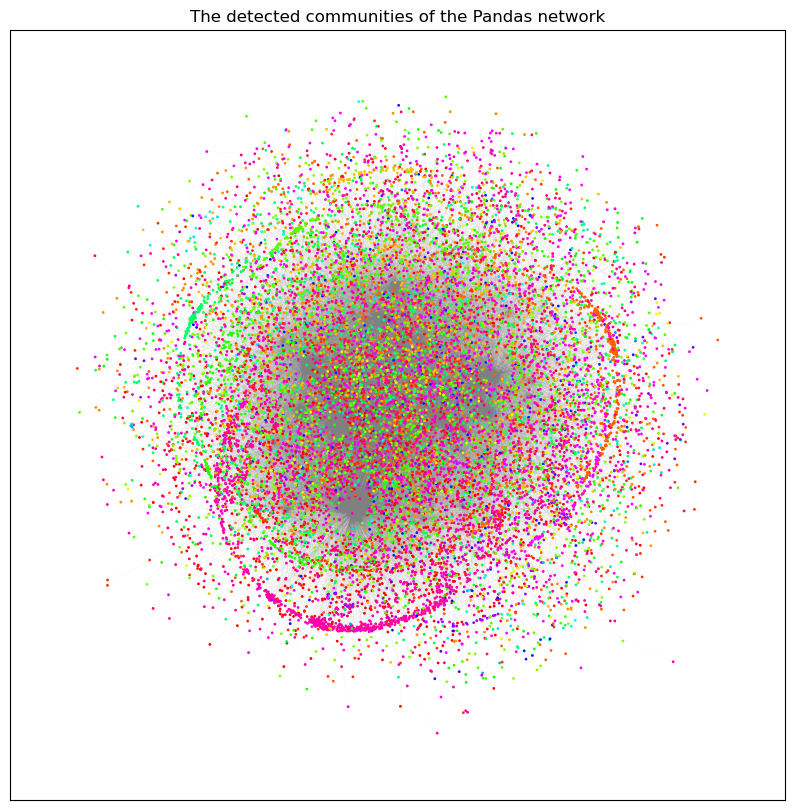

In [39]:
cmap = plt.get_cmap('hsv', len(louv_comm))

color_map = []

for n in G_tensorflow_und.nodes():
    for i in range(len(louv_comm)):
        if n in louv_comm[i]:
            color_map.append(cmap(i))
            break

plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(
    G_tensorflow_und, 
    pos=pose, 
    node_color=color_map,
    node_size=1,
    alpha=1.0
)
nx.draw_networkx_edges(
    G_tensorflow_und, 
    pos=pose, 
    edge_color='gray',  
    width=0.1,
    alpha=0.2
)
plt.title("The detected communities of the Pandas network")
plt.show()

In [ ]:
# print(nx.average_shortest_path_length(G_tensorflow.to_undirected()))
# print(nx.average_shortest_path_length(G_pandas.to_undirected()))
# print(nx.average_shortest_path_length(G_networkx.to_undirected()))

In [ ]:
read_raw_data = open("raw_data_tensorflow.txt", 'r', encoding='utf-8')

path = "top10-tensorflow/"

for (user, _) in in_degree_sequence_tensorflow[0:10]:
    read_raw_data.seek(0)

    all_issues = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("issue:" + user):
            next(iterator)
            next(iterator)
            cur_issue = next(iterator)
            cur_issue += next(iterator)

            all_issues += cur_issue

    with open(path + "in-" + user, 'w', encoding='utf-8') as f:
        f.write(all_issues)


for (user, _) in out_degree_sequence_tensorflow[0:10]:
    read_raw_data.seek(0)

    all_comments = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("comment:" + user):
            cur_comment = next(iterator)

            all_comments += cur_comment

    with open(path + "out-" + user, 'w', encoding='utf-8') as f:
        f.write(all_comments)

read_raw_data.close()
    

In [ ]:
read_raw_data = open("raw_data_pandas.txt", 'r', encoding='utf-8')

path_pandas = "top10-pandas/"

for (user, _) in in_degree_sequence_pandas[0:10]:
    read_raw_data.seek(0)

    all_issues = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("issue:" + user):
            next(iterator)
            next(iterator)
            cur_issue = next(iterator)
            cur_issue += next(iterator)

            all_issues += cur_issue

    with open(path_pandas + "in-" + user, 'w', encoding='utf-8') as f:
        f.write(all_issues)


for (user, _) in out_degree_sequence_pandas[0:10]:
    read_raw_data.seek(0)

    all_comments = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("comment:" + user):
            cur_comment = next(iterator)

            all_comments += cur_comment

    with open(path_pandas + "out-" + user, 'w', encoding='utf-8') as f:
        f.write(all_comments)

read_raw_data.close()

In [ ]:
read_raw_data = open("raw_data_networkx.txt", 'r', encoding='utf-8')

path_networkx = "top10-networkx/"

for (user, _) in in_degree_sequence_networkx[0:10]:
    read_raw_data.seek(0)

    all_issues = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("issue:" + user):
            next(iterator)
            next(iterator)
            cur_issue = next(iterator)
            cur_issue += next(iterator)

            all_issues += cur_issue

    with open(path_networkx + "in-" + user, 'w', encoding='utf-8') as f:
        f.write(all_issues)


for (user, _) in out_degree_sequence_networkx[0:10]:
    read_raw_data.seek(0)

    all_comments = ""

    iterator = iter(read_raw_data)    

    for line in iterator:
        if line.startswith("comment:" + user):
            cur_comment = next(iterator)

            all_comments += cur_comment

    with open(path_networkx + "out-" + user, 'w', encoding='utf-8') as f:
        f.write(all_comments)

read_raw_data.close()
    

In [28]:
def text_without_stopwords(text):
    stopwords = nltk.corpus.stopwords.words('english')
    return [w.lower() for w in text if w.lower() not in stopwords and w.isalpha()]
     
files = os.listdir(path)

for file in files:
    with open(path + file, 'r', encoding="utf-8") as f:
        tokenizer = nltk.TreebankWordTokenizer()

        tokens = tokenizer.tokenize(f.read())
        print(nltk.FreqDist(text_without_stopwords(tokens)).most_common(50))

[('tensorflow', 245), ('file', 183), ('line', 162), ('std', 159), ('https', 124), ('optimized', 118), ('char', 106), ('const', 80), ('import', 78), ('error', 73), ('tf', 58), ('python', 57), ('eigen', 51), ('module', 50), ('run', 43), ('build', 43), ('version', 43), ('op', 41), ('use', 39), ('long', 37), ('tensor', 35), ('fails', 35), ('cuda', 35), ('float', 34), ('like', 33), ('graph', 33), ('call', 32), ('return', 31), ('last', 31), ('support', 31), ('gpu', 31), ('sess', 28), ('could', 27), ('following', 27), ('ops', 27), ('device', 26), ('memory', 26), ('recent', 25), ('type', 25), ('would', 25), ('library', 24), ('x', 24), ('failed', 23), ('default', 23), ('namespace', 23), ('node', 22), ('print', 22), ('traceback', 21), ('variable', 21), ('output', 20)]
[('https', 116), ('tensorflow', 42), ('using', 41), ('image', 38), ('cuda', 37), ('gpu', 31), ('see', 30), ('build', 30), ('root', 30), ('op', 30), ('use', 28), ('tf', 24), ('graph', 24), ('library', 22), ('name', 22), ('model', 22

In [ ]:
for file in files:
    with open(path + file, 'r', encoding="utf-8") as f:
        tokenizer = nltk.TreebankWordTokenizer()

        tokens = tokenizer.tokenize(f.read())

        text1_without = text_without_stopwords(tokens)

        all_bigrams = list(nltk.bigrams(text1_without))
            
        fdist_bigrams = nltk.FreqDist(all_bigrams)

        print(fdist_bigrams.most_common(50))

[(('file', 'line'), 145), (('optimized', 'optimized'), 110), (('std', 'char'), 93), (('char', 'std'), 73), (('tensorflow', 'tensorflow'), 46), (('line', 'module'), 44), (('std', 'std'), 33), (('module', 'import'), 30), (('const', 'tensorflow'), 30), (('import', 'tensorflow'), 26), (('tensorflow', 'const'), 24), (('tensorflow', 'std'), 23), (('tensorflow', 'tf'), 21), (('recent', 'call'), 21), (('call', 'last'), 21), (('long', 'long'), 21), (('traceback', 'recent'), 20), (('last', 'file'), 20), (('line', 'file'), 19), (('char', 'const'), 17), (('eigen', 'float'), 17), (('tensorflow', 'anonymous'), 17), (('anonymous', 'namespace'), 16), (('please', 'specify'), 15), (('eigen', 'eigen'), 15), (('std', 'tensorflow'), 14), (('cuda', 'library'), 13), (('const', 'std'), 13), (('feature', 'request'), 13), (('std', 'void'), 13), (('float', 'eigen'), 11), (('min', 'median'), 11), (('median', 'mean'), 11), (('import', 'file'), 10), (('successfully', 'opened'), 10), (('opened', 'cuda'), 10), (('lib

In [34]:
read_raw_data = open("raw_data_tensorflow.txt", 'r', encoding='utf-8')

tokenizer = nltk.TreebankWordTokenizer()

random.seed(42)

all_issues = ""

i = 0

read_raw_data.seek(0)

iterator = iter(read_raw_data)    

for line in iterator:
    if line.startswith("issue:") and random.randint(1, 10) == 1:
        i += 1
        next(iterator)
        next(iterator)
        cur_issue = next(iterator)
        cur_issue += next(iterator)

        all_issues += cur_issue

read_raw_data.close()

all_issues_tokens = tokenizer.tokenize(all_issues)

print(i)

print(len(nltk.FreqDist(text_without_stopwords(all_issues_tokens))))


3936
14183


In [35]:
freq_dist_all_issues = nltk.FreqDist(text_without_stopwords(all_issues_tokens))

In [36]:
print(freq_dist_all_issues.most_common(10))

[('tensorflow', 14233), ('file', 10451), ('version', 9199), ('line', 8242), ('error', 5797), ('model', 5641), ('source', 5550), ('import', 5372), ('code', 5009), ('https', 4510)]


In [ ]:
read_raw_data = open("raw_data_networkx.txt", 'r', encoding='utf-8')

random.seed(42)

all_issues = ""

i = 0

read_raw_data.seek(0)

iterator = iter(read_raw_data)    

for line in iterator:
    if line.startswith("issue:"):
        i += 1
        next(iterator)
        next(iterator)
        cur_issue = next(iterator)
        cur_issue += next(iterator)

        all_issues += cur_issue

read_raw_data.close()

print(i)

all_issues_tokens = tokenizer.tokenize(all_issues)

print(len(nltk.FreqDist(text_without_stopwords(all_issues_tokens))))


3131
9632


In [ ]:
read_raw_data = open("raw_data_pandas.txt", 'r', encoding='utf-8')

random.seed(42)

all_issues = ""

read_raw_data.seek(0)

iterator = iter(read_raw_data)    

labels_counts = Counter()

more_one = 0

for line in iterator:
    if line.startswith("issue:"):
        labels = next(iterator).strip().split('|')
        
        if len(labels) > 1:
            more_one += 1

        labels_counts.update(labels)

read_raw_data.close()

all_issues_tokens = tokenizer.tokenize(all_issues)

print(more_one)
print(labels_counts)


16667
Counter({'Bug': 7358, 'Enhancement': 2548, '': 2212, 'Docs': 2122, 'good first issue': 1701, 'Usage Question': 1618, 'Indexing': 1488, 'Needs Triage': 1457, 'Datetime': 1330, 'Groupby': 1272, 'API Design': 1193, 'Reshaping': 1189, 'Dtype Conversions': 1145, 'Duplicate Report': 1091, 'Regression': 926, 'Testing': 833, 'Performance': 826, 'IO CSV': 808, 'Closing Candidate': 786, 'Missing-data': 750, 'MultiIndex': 707, 'Needs Tests': 691, 'Needs Info': 681, 'Error Reporting': 628, 'Numeric Operations': 588, 'Visualization': 570, 'CI': 557, 'Categorical': 556, 'IO Data': 542, 'Build': 537, 'Timezones': 526, 'Compat': 520, 'Needs Discussion': 507, 'IO Excel': 436, 'Deprecate': 402, 'ExtensionArray': 396, 'Output-Formatting': 387, 'Timedelta': 343, 'Strings': 303, 'Clean': 282, 'IO JSON': 278, 'Apply': 275, 'Algos': 270, 'IO HDF5': 256, 'Frequency': 253, 'IO SQL': 250, 'Resample': 248, 'Arrow': 246, 'Window': 239, 'NA - MaskedArrays': 236, 'Internals': 232, 'Index': 214, 'Period': 204,

In [41]:
read_raw_data = open("raw_data_tensorflow.txt", 'r', encoding='utf-8')

random.seed(42)

all_issues = ""

i = 0

read_raw_data.seek(0)

iterator = iter(read_raw_data)    

for line in iterator:
    if line.startswith("issue:"):
        i += 1

read_raw_data.close()

print(i)


39467
